<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/PR_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SMART SURVEILLANCE IMAGE CLASSIFICATION
TensorFlow version: 2.20.0

Dataset extracted successfully.

Training folder: /content/dataset/catsAndDogs40/train
Testing folder : /content/dataset/catsAndDogs40/test

Dataset Information:
CAT   -> Training: 32 | Testing: 8
DOG   -> Training: 32 | Testing: 8

MODEL 1: CUSTOM CNN
Found 64 images belonging to 2 classes.
Found 16 images belonging to 2 classes.

Training CNN...
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.5000 - loss: 0.7195
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.5000 - loss: 0.6858
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.4531 - loss: 0.6948
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.5469 - loss: 0.6675
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.5312 - loss: 0.6481
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.7031 - loss: 0.6576
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.6719 - loss: 0

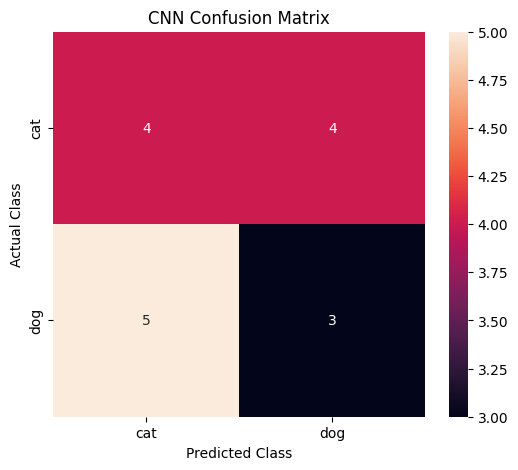


MODEL 2: MOBILENETV2
Found 64 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training MobileNetV2...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.7812 - loss: 0.4994
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9844 - loss: 0.1047
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 1.0000 - loss: 0.0424
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 1.0000 - loss: 0.0143
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0090
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0104
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0080
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0053
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 -

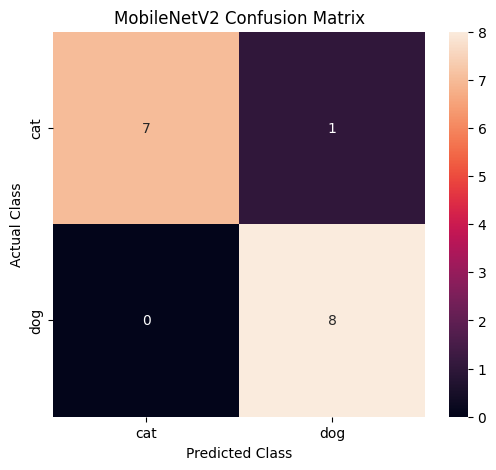


FINAL PERFORMANCE COMPARISON


      Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
        CNN         43.75          43.65       43.75         43.53
MobileNetV2         93.75          94.44       93.75         93.73


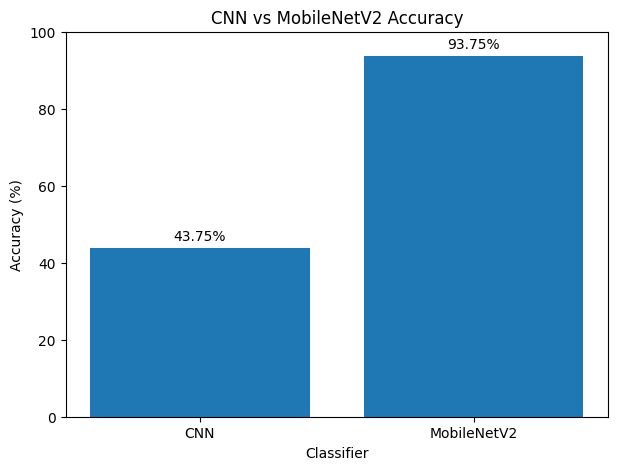

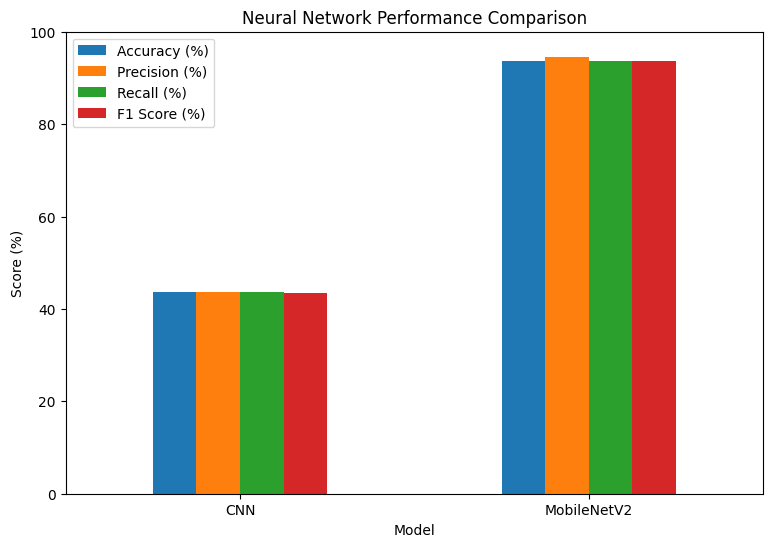


IMAGE RECOGNITION DEMONSTRATION

Actual Class       : cat
CNN Prediction     : cat
CNN Confidence     : 63.5 %


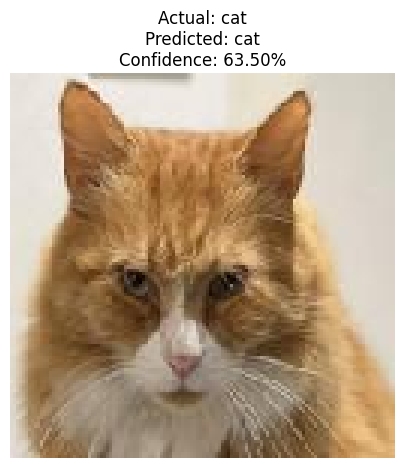


CONCLUSION
MobileNetV2 achieved higher test accuracy on this small dataset.

The experiment compared CNN and MobileNetV2 for image classification using a small Cats and Dogs dataset.
Accuracy, precision, recall, F1-score, confusion matrices and individual image recognition were evaluated.

Note: Because the dataset is very small, the measured accuracy can vary considerably between individual images.


In [ ]:
# ============================================================
# SMART SURVEILLANCE IMAGE CLASSIFICATION
# Dataset: Cats and Dogs 40
# Models: CNN and MobileNetV2
# ============================================================

# -------------------- 1. INSTALL --------------------
!pip -q install scikit-learn seaborn

# -------------------- 2. IMPORT LIBRARIES --------------------
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("=" * 60)
print("SMART SURVEILLANCE IMAGE CLASSIFICATION")
print("=" * 60)
print("TensorFlow version:", tf.__version__)


# -------------------- 3. EXTRACT DATASET --------------------
zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("\nDataset extracted successfully.")


# -------------------- 4. FIND DATASET FOLDERS --------------------
# Automatically locate train/test folders

train_dir = None
test_dir = None

for root, dirs, files in os.walk(extract_path):

    if os.path.basename(root).lower() == "train":
        if os.path.isdir(os.path.join(root, "cat")) and \
           os.path.isdir(os.path.join(root, "dog")):
            train_dir = root

    if os.path.basename(root).lower() == "test":
        if os.path.isdir(os.path.join(root, "cat")) and \
           os.path.isdir(os.path.join(root, "dog")):
            test_dir = root

if train_dir is None or test_dir is None:
    raise Exception(
        "Could not find train/test folders containing cat and dog folders."
    )

print("\nTraining folder:", train_dir)
print("Testing folder :", test_dir)


# -------------------- 5. DATASET INFORMATION --------------------
classes = ["cat", "dog"]

print("\nDataset Information:")

for class_name in classes:

    train_count = len(
        os.listdir(os.path.join(train_dir, class_name))
    )

    test_count = len(
        os.listdir(os.path.join(test_dir, class_name))
    )

    print(
        f"{class_name.upper():5s} -> "
        f"Training: {train_count} | Testing: {test_count}"
    )


# -------------------- 6. IMAGE SETTINGS --------------------
IMG_SIZE = (128, 128)
BATCH_SIZE = 8


# ============================================================
# MODEL 1: CNN
# ============================================================

print("\n" + "=" * 60)
print("MODEL 1: CUSTOM CNN")
print("=" * 60)


# -------------------- 7. CNN DATA GENERATOR --------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


# -------------------- 8. BUILD CNN --------------------
cnn = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(2, 2),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(2, 2),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# -------------------- 9. COMPILE CNN --------------------
cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# -------------------- 10. TRAIN CNN --------------------
print("\nTraining CNN...")

cnn_history = cnn.fit(
    train_generator,
    epochs=15,
    verbose=1
)


# -------------------- 11. TEST CNN --------------------
cnn_loss, cnn_accuracy = cnn.evaluate(
    test_generator,
    verbose=0
)

print(
    "\nCNN Test Accuracy:",
    round(cnn_accuracy * 100, 2),
    "%"
)


# -------------------- 12. CNN PREDICTIONS --------------------
test_generator.reset()

cnn_predictions = cnn.predict(
    test_generator,
    verbose=0
)

cnn_pred_classes = (
    cnn_predictions >= 0.5
).astype(int).flatten()

actual_classes = test_generator.classes


# -------------------- 13. CNN REPORT --------------------
print("\nCNN Classification Report:")
print(
    classification_report(
        actual_classes,
        cnn_pred_classes,
        target_names=classes,
        zero_division=0
    )
)


# -------------------- 14. CNN CONFUSION MATRIX --------------------
cnn_cm = confusion_matrix(
    actual_classes,
    cnn_pred_classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")

plt.show()


# ============================================================
# MODEL 2: MOBILENETV2
# ============================================================

print("\n" + "=" * 60)
print("MODEL 2: MOBILENETV2")
print("=" * 60)


# -------------------- 15. MOBILENET DATA --------------------
mobile_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

mobile_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

mobile_train = mobile_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

mobile_test = mobile_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


# -------------------- 16. LOAD MOBILENETV2 --------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False


# -------------------- 17. BUILD MOBILENET CLASSIFIER --------------------
mobilenet = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# -------------------- 18. COMPILE --------------------
mobilenet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# -------------------- 19. TRAIN --------------------
print("\nTraining MobileNetV2...")

mobile_history = mobilenet.fit(
    mobile_train,
    epochs=10,
    verbose=1
)


# -------------------- 20. TEST --------------------
mobile_loss, mobile_accuracy = mobilenet.evaluate(
    mobile_test,
    verbose=0
)

print(
    "\nMobileNetV2 Test Accuracy:",
    round(mobile_accuracy * 100, 2),
    "%"
)


# -------------------- 21. PREDICTIONS --------------------
mobile_test.reset()

mobile_predictions = mobilenet.predict(
    mobile_test,
    verbose=0
)

mobile_pred_classes = (
    mobile_predictions >= 0.5
).astype(int).flatten()

actual_mobile = mobile_test.classes


# -------------------- 22. CLASSIFICATION REPORT --------------------
print("\nMobileNetV2 Classification Report:")

print(
    classification_report(
        actual_mobile,
        mobile_pred_classes,
        target_names=classes,
        zero_division=0
    )
)


# -------------------- 23. CONFUSION MATRIX --------------------
mobile_cm = confusion_matrix(
    actual_mobile,
    mobile_pred_classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    mobile_cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()


# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 60)


# -------------------- 24. METRICS --------------------
cnn_precision, cnn_recall, cnn_f1, _ = \
    precision_recall_fscore_support(
        actual_classes,
        cnn_pred_classes,
        average="weighted",
        zero_division=0
    )

mobile_precision, mobile_recall, mobile_f1, _ = \
    precision_recall_fscore_support(
        actual_mobile,
        mobile_pred_classes,
        average="weighted",
        zero_division=0
    )


# -------------------- 25. RESULTS TABLE --------------------
results = pd.DataFrame({

    "Model": [
        "CNN",
        "MobileNetV2"
    ],

    "Accuracy (%)": [
        cnn_accuracy * 100,
        mobile_accuracy * 100
    ],

    "Precision (%)": [
        cnn_precision * 100,
        mobile_precision * 100
    ],

    "Recall (%)": [
        cnn_recall * 100,
        mobile_recall * 100
    ],

    "F1 Score (%)": [
        cnn_f1 * 100,
        mobile_f1 * 100
    ]
})

results = results.round(2)

print("\n")
print(results.to_string(index=False))


# -------------------- 26. ACCURACY GRAPH --------------------
plt.figure(figsize=(7, 5))

bars = plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Classifier")
plt.title("CNN vs MobileNetV2 Accuracy")
plt.ylim(0, 100)

for bar, value in zip(
    bars,
    results["Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()


# -------------------- 27. ALL METRICS GRAPH --------------------
results_plot = results.set_index("Model")

results_plot[
    [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.title("Neural Network Performance Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()


# ============================================================
# RECOGNITION DEMONSTRATION
# ============================================================

print("\n" + "=" * 60)
print("IMAGE RECOGNITION DEMONSTRATION")
print("=" * 60)


# -------------------- 28. GET TEST IMAGES --------------------
all_test_images = []

for class_name in classes:

    class_folder = os.path.join(
        test_dir,
        class_name
    )

    for filename in os.listdir(class_folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            all_test_images.append(
                os.path.join(
                    class_folder,
                    filename
                )
            )


# Select random image
random.seed(42)

image_path = random.choice(
    all_test_images
)

actual_class = os.path.basename(
    os.path.dirname(image_path)
)


# -------------------- 29. CNN RECOGNITION --------------------
image = load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = img_to_array(image)

image_array = image_array / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

cnn_probability = cnn.predict(
    image_array,
    verbose=0
)[0][0]

if cnn_probability >= 0.5:

    cnn_class = "dog"
    cnn_confidence = cnn_probability

else:

    cnn_class = "cat"
    cnn_confidence = 1 - cnn_probability


# -------------------- 30. DISPLAY RESULT --------------------
print("\nActual Class       :", actual_class)
print(
    "CNN Prediction     :",
    cnn_class
)
print(
    "CNN Confidence     :",
    round(cnn_confidence * 100, 2),
    "%"
)


plt.figure(figsize=(6, 5))

plt.imshow(image)

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {cnn_class}\n"
    f"Confidence: {cnn_confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()


# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

if cnn_accuracy > mobile_accuracy:

    print(
        "CNN achieved higher test accuracy on this small dataset."
    )

elif mobile_accuracy > cnn_accuracy:

    print(
        "MobileNetV2 achieved higher test accuracy on this small dataset."
    )

else:

    print(
        "Both models achieved the same test accuracy."
    )

print(
    "\nThe experiment compared CNN and MobileNetV2 "
    "for image classification using a small Cats and Dogs dataset."
)

print(
    "Accuracy, precision, recall, F1-score, confusion matrices "
    "and individual image recognition were evaluated."
)

print(
    "\nNote: Because the dataset is very small, the measured "
    "accuracy can vary considerably between individual images."
)

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

# Assuming the uploaded file is named 'archive (3).zip'
# If your uploaded file has a different name, please update the 'zip_path' variable below accordingly.
# zip_path = f'/content/{list(uploaded.keys())[0]}'


Saving archive (3).zip to archive (3).zip
User uploaded file "archive (3).zip"
